# The High-Yield Muni premium — a quantitative teardown 🔬
### HAC spread + bootstrap CI · excess Sharpe race · era/crisis cut · tax-equivalent yield & after-tax race · drawdowns & one-switch costs · synthetic faithful-engine control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Credit + tax wrapper?: Half true](https://img.shields.io/badge/Credit_%2B_tax_wrapper%3F-Half_true-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The HY-muni credit premium is graded here **on the live vehicles only**: HYD vs MUB/TFI 2009→2026, HYG as the *taxable-HY* yardstick for the tax comparison, BIL as the tradable risk-free. The tax-equivalent leg is arithmetic; the credit leg is the one on trial.

> ⚠️ **Data note.** yfinance auto-adjusted closes = **total-return, net-of-fee** ETF tape (HYD ER 0.35%, MUB 0.05%, TFI 0.23%, HYG 0.49% already inside); a second price-only pull backs out the income (coupon) leg. As-of **2026-06-30** (last complete month), fingerprint `db0172501766`. Tax convention: top-bracket **40.8%** (37% + 3.8% NIIT), muni coupons exempt. Numbers in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab)
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from hy_muni import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX = data.load_prices()                       # total-return closes, frozen as-of
    PR = data.load_price_only()                   # price-only closes (income leg)
    M = st.monthly_returns(PX, asof=data.AS_OF)
    INC = st.monthly_income(PX, PR, asof=data.AS_OF)
    MC = st.align_common(M, ["HYD", "MUB", "TFI", "HYG", "BIL"])   # HYD era
    RATE = data.TOP_MARGINAL_RATE
else:
    PX = PR = M = INC = MC = None
    RATE = 0.408
print("real ETF cache present:", HAVE_REAL,
      "| HYD-era months:", (0 if MC is None else len(MC)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-30', 'fingerprint': 'db0172501766', 'start': '2009-03', 'end': '2026-06', 'n_months': 208, 'years': 17.3, 'rate': 40.8, 'spread_bps': 20.21, 'spread_t': 1.8, 'spread_pp': 2.43, 'boot_lo': -1.44, 'boot_hi': 42.23, 'boot_fracneg': 0.036, 'ann': {'HYD': 5.38, 'MUB': 3.2, 'TFI': 3.01, 'HYG': 7.26, 'BIL': 1.25}, 'sharpe': {'HYD': 0.478, 'MUB': 0.408, 'TFI': 0.341, 'HYG': 0.732}, 'sharpe_adv': 0.069, 'eras': [('2009-2016', 27.4, 1.85, 94), ('2017-2026', 14.3, 0.91, 114), ('2020 COVID', -18.4, -0.15, 12), ('2022 rate shock', -78.0, -4.35, 12)], 'halves': [('2009-2017', 1.0, 0.87, 0.13), ('2018-2026', 0.11, -0.04, 0.15)], 'income': {'HYD': 5.43, 'MUB': 2.71, 'HYG': 6.04}, 'tey': 9.17, 'aftertax_ann': {'HYD': 5.38, 'MUB': 3.2, 'HYG': 4.67}, 'aftertax_sharpe': {'HYD': 0.53, 'MUB': 0.51, 'HYG': 0.5}, 'dd': {'HYD': -35.6, 'MUB': -13.7, 'HYG': -22.0}, 'dd_dates': {'HYD': '2020-02-26 - 2020-03-18', 'MUB': '2020-03-09 - 2020-03-19', 'HYG': '2020-02-13 - 2020-03-23'}, 'costs': [(5.0, 0.6, 242), (15.0, 1.7, 241), (30.0, 3.5, 239)], 'gross_bps': 243, 'syn': [(0.0, 5.18, 1.13, -3.5, 14.1, 0.128), (3.0, 30.18, 6.59, 21.5, 39.1, 0.0)]}


real ETF cache present: True | HYD-era months: 208


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | HYD − MUB = **+20.21 bps/mo** (HAC **t = 1.80**, n = 208); bootstrap 95% CI **[-1.44, 42.23]** touches zero; excess-Sharpe edge over MUB only **+0.07**; 2022 spread **−78 bps/mo (t = −4.35)**. |
| **Tradability** | `FRAGILE` | One switch, drag ≤ 3.5 bps/yr vs **+239 bps/yr net** (not a Mirage); but thin Signal + crisis-fragile (DD **-35.6% vs -13.7%**) + tax pickup only for top-bracket taxable accounts. |
| **Credit + tax wrapper?** | `HALF TRUE` | Wrapper real: TEY **9.17%** vs HYG **6.04%**, after-tax HYD **5.38%** > HYG **4.67%**. Credit premium won't certify. |

> 💡 In plain words: the tax break is a real, mechanical yield pickup; the credit premium over investment-grade muni is directionally positive but statistically thin and blows up in stress — so the honest stamps are Weak / Fragile, not green.

## 1 · The claim, steelmanned

HY munis carry (a) a **credit/liquidity spread** over IG munis and (b) a **tax exemption** on coupon income. For a top-bracket investor the second is exact; the first is the empirical question. With monthly total returns and the T-bill (BIL) as the risk-free:

$$\text{spread}_t = r_{HYD,t} - r_{MUB,t}, \qquad \text{TEY}_{HYD} = \frac{y^{coupon}_{HYD}}{1-\tau}$$

- **H₁ (credit premium exists).** Mean(HYD − MUB) > 0 with HAC t ≥ 2, a bootstrap CI clear of zero, holding across sub-eras.
- **H₂ (tax wrapper wins).** TEY(HYD) > y(HYG) and after-tax HYD ≥ after-tax HYG.
- **H₃ (bankable).** One-switch cost drag ≪ net spread; the crisis drawdown is survivable.

We find **H₂ clearly supported** (arithmetic), **H₁ only weakly** (t = 1.80, CI to zero, 2022 inversion), so H₃ lands on **Fragile**.

## 2 · So what? — what rides on each answer

The dangerous failure mode is **selling a liquidity premium as a free lunch**. Muni defaults are rare, so the HY-muni spread is mostly compensation for *illiquidity* — a premium that is positive in calm and sharply negative in a scramble (Schwert 2017 decomposes exactly this). If we certified it as `Real/Investable` on the calm-period average, we'd be handing out a stamp the 2020/2022 tape rips up. The tax leg is different: it is contractual, so it earns credit even though it is not, by itself, a *risk-adjusted outperformance*.

## 3 · How we'd know — the protocol

- **Tape.** yfinance total-return net-of-fee closes; HYD-era common sample **2009-03 → 2026-06** (208 months); as-of 2026-06-30; partial months dropped; fingerprint `db0172501766`.
- **H₁.** HAC (Newey-West, Bartlett, rule-of-thumb lags) t on the monthly HYD − MUB spread + a circular-block bootstrap mean CI; excess-vs-excess Sharpe race on BIL; an era cut and the 2020/2022 crisis windows.
- **H₂.** Income leg = total-return − price-return; tax-equivalent yield y/(1−τ); after-tax total-return and Sharpe race for a top-bracket investor (muni coupon exempt, HYG coupon taxed, cash leg taxed).
- **H₃.** One-switch cost drag (2 legs × one-way bps over the horizon); daily max-DD.
- **Machinery proof.** Synthetic world HYD = premium + 1.15·MUB + ε with a planted knob: null must stay under t = 2 with a CI straddling zero; planted +3%/yr must light up. Never market evidence.

## 4 · The teardown

### 4a · H₁ — the credit spread, its HAC t and bootstrap CI

Cumulative relative strength (HYD/MUB) plus the monthly spread's HAC test and a block-bootstrap mean interval.

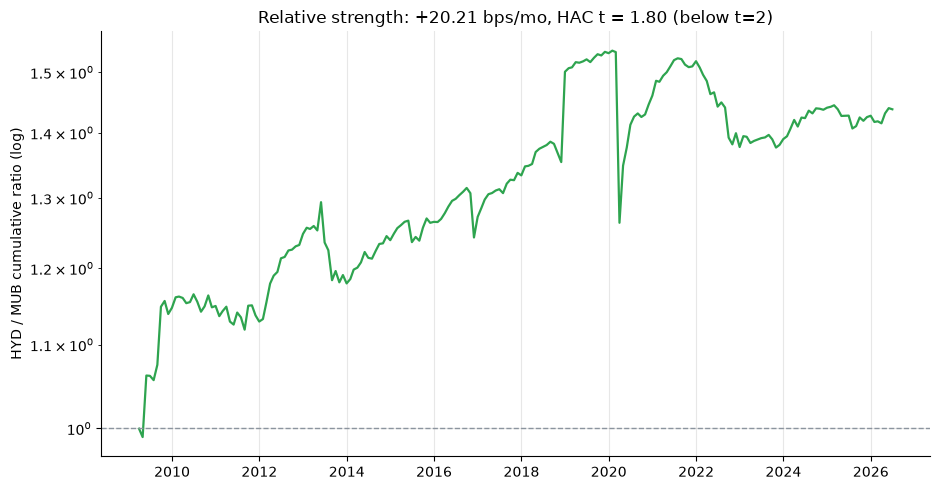

HYD - MUB: +20.21 bps/mo  HAC t = +1.80  (n=208, lags=4)
bootstrap 95% mean CI: [-1.44, +42.23] bps/mo  frac<0=0.036
excess Sharpe: HYD 0.478  MUB 0.408  TFI 0.341  HYG 0.732


In [2]:
if HAVE_REAL:
    sp = st.premium_series(MC)
    h = st.hac_mean(sp.values)
    boot = st.bootstrap_mean_ci(sp.values)
    rel = (1 + MC[['HYD','MUB']]).cumprod()
    ratio = rel['HYD'] / rel['MUB']
    fig, ax = plt.subplots()
    ax.plot(ratio.index, ratio, c=GREEN, lw=1.6)
    ax.axhline(1.0, c=GREY, ls='--', lw=1)
    ax.set_yscale('log'); ax.set_ylabel('HYD / MUB cumulative ratio (log)')
    ax.set_title(f"Relative strength: +{h['mean_bps']:.2f} bps/mo, HAC t = {h['tstat']:.2f} (below t=2)")
    plt.tight_layout(); plt.show()
    print(f"HYD - MUB: {h['mean_bps']:+.2f} bps/mo  HAC t = {h['tstat']:+.2f}  (n={h['n']}, lags={h['lags']})")
    print(f"bootstrap 95% mean CI: [{boot['ci_low_bps']:+.2f}, {boot['ci_high_bps']:+.2f}] bps/mo  frac<0={boot['frac_negative']:.3f}")
    print(f"excess Sharpe: HYD {st.sharpe_excess(MC,'HYD'):.3f}  MUB {st.sharpe_excess(MC,'MUB'):.3f}  "
          f"TFI {st.sharpe_excess(MC,'TFI'):.3f}  HYG {st.sharpe_excess(MC,'HYG'):.3f}")
else:
    print('cache missing - frozen:', R['spread_bps'], R['spread_t'], (R['boot_lo'], R['boot_hi']), R['sharpe'])

> 💡 In plain words: **+20.21 bps/mo** for 17.3 years, but at **HAC t = 1.80** it is *below* the desk's t ≥ 2 bar, and the bootstrap 95% CI **[-1.44, 42.23]** includes zero. The excess-Sharpe race gives HYD **0.48** vs MUB **0.41** — a thin **+0.07** advantage. Directionally right, not robust.

### 4b · The era cut & the crises — where illiquidity bites

Neither half certifies alone, and the premium *inverts* in the 2020/2022 stress windows.

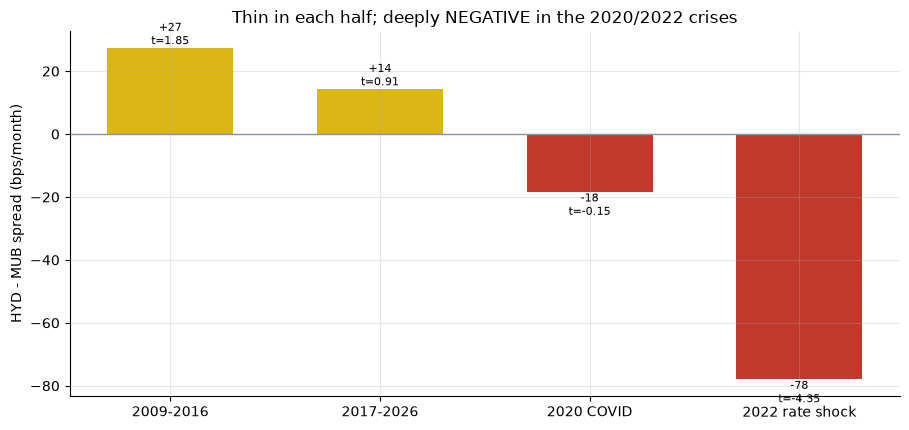

2009-2016          +27.4 bps/mo  HAC t +1.85
2017-2026          +14.3 bps/mo  HAC t +0.91
2020 COVID         -18.4 bps/mo  HAC t -0.15
2022 rate shock    -78.0 bps/mo  HAC t -4.35


In [3]:
if HAVE_REAL:
    sp = st.premium_series(MC)
    eras = st.era_table(sp, [('2009-03','2016-12','2009-2016'),('2017-01','2026-06','2017-2026'),
                             ('2020-01','2020-12','2020 COVID'),('2022-01','2022-12','2022 rate shock')])
    rows = [(e['label'], e['mean_bps'], e['tstat']) for e in eras]
else:
    rows = [(e[0], e[1], e[2]) for e in R['eras']]
fig, ax = plt.subplots(figsize=(9.2, 4.4))
cols = [GREEN if v[2] >= 2 else (RED if v[1] < 0 else AMBER) for v in rows]
ax.bar([r[0] for r in rows], [r[1] for r in rows], color=cols, width=.6)
for i, r in enumerate(rows): ax.annotate(f'{r[1]:+.0f}\nt={r[2]:.2f}', (i, r[1]), ha='center', va='bottom' if r[1]>=0 else 'top', fontsize=8)
ax.axhline(0, c=GREY, lw=1)
ax.set_ylabel('HYD - MUB spread (bps/month)')
ax.set_title('Thin in each half; deeply NEGATIVE in the 2020/2022 crises')
plt.tight_layout(); plt.show()
for lab, m_, t in rows: print(f'{lab:16s} {m_:+7.1f} bps/mo  HAC t {t:+.2f}')

> 💡 In plain words: 2009-2016 was the strongest stretch (+27 bps/mo, t = 1.85) and 2017-2026 far weaker (t = 0.91); **neither clears t = 2**. And in the crises the spread is **-18 bps/mo** (2020) and **-78 bps/mo at t = -4.35** (2022) — HY-muni *lost* to safe muni precisely when liquidity evaporated. This is the illiquidity premium showing its teeth.

### 4c · H₂ — the tax wrapper (the part that works)

Tax-equivalent yield and the after-tax total-return race for a top-bracket investor.

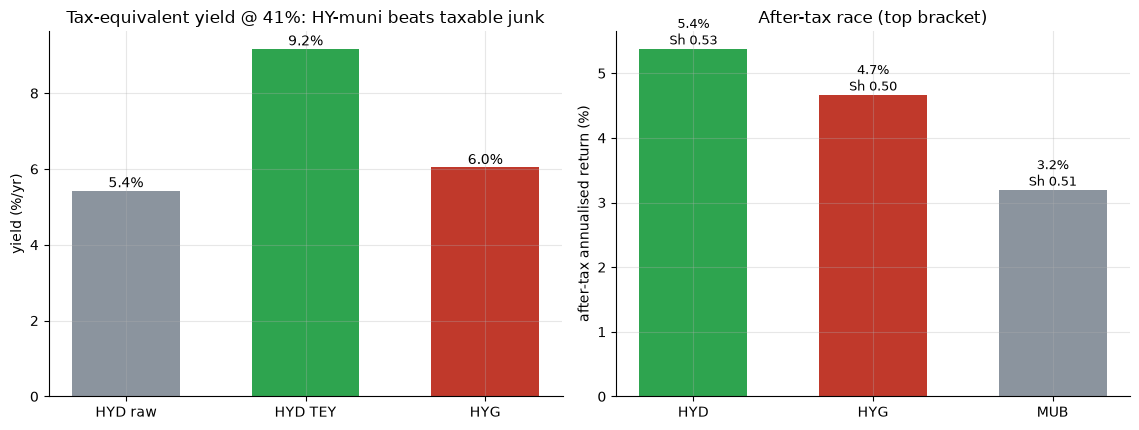

income yield: HYD 5.43%  MUB 2.71%  HYG 6.04%
HYD TEY 9.17%  vs HYG 6.04%
after-tax ann: HYD 5.38%  HYG 4.67%  MUB 3.20%
after-tax exSharpe: HYD +0.53  HYG +0.50  MUB +0.51


In [4]:
if HAVE_REAL:
    iy = st.income_yields(INC.loc[MC.index], ['HYD','MUB','HYG'])
    tey = st.tax_equivalent_yield(iy['HYD'], RATE)
    at_hyd = st.after_tax_returns(MC, INC.loc[MC.index], 'HYD', RATE, tax_exempt=True)
    at_mub = st.after_tax_returns(MC, INC.loc[MC.index], 'MUB', RATE, tax_exempt=True)
    at_hyg = st.after_tax_returns(MC, INC.loc[MC.index], 'HYG', RATE, tax_exempt=False)
    at_ann = {'HYD': st.ann_return(at_hyd), 'MUB': st.ann_return(at_mub), 'HYG': st.ann_return(at_hyg)}
    at_sh = {'HYD': st.after_tax_sharpe(at_hyd, MC, RATE), 'MUB': st.after_tax_sharpe(at_mub, MC, RATE),
             'HYG': st.after_tax_sharpe(at_hyg, MC, RATE)}
else:
    iy = R['income']; tey = R['tey']; at_ann = R['aftertax_ann']; at_sh = R['aftertax_sharpe']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.5, 4.4))
a1.bar(['HYD raw','HYD TEY','HYG'], [iy['HYD'], tey, iy['HYG']], color=[GREY, GREEN, RED], width=.6)
for i, v in enumerate([iy['HYD'], tey, iy['HYG']]): a1.annotate(f'{v:.1f}%', (i, v), ha='center', va='bottom')
a1.set_ylabel('yield (%/yr)'); a1.set_title(f'Tax-equivalent yield @ {RATE*100:.0f}%: HY-muni beats taxable junk')
labs = ['HYD','HYG','MUB']
a2.bar(labs, [at_ann[k] for k in labs], color=[GREEN, RED, GREY], width=.6)
for i, k in enumerate(labs): a2.annotate(f"{at_ann[k]:.1f}%\nSh {at_sh[k]:.2f}", (i, at_ann[k]), ha='center', va='bottom', fontsize=9)
a2.set_ylabel('after-tax annualised return (%)'); a2.set_title('After-tax race (top bracket)')
plt.tight_layout(); plt.show()
print(f"income yield: HYD {iy['HYD']:.2f}%  MUB {iy['MUB']:.2f}%  HYG {iy['HYG']:.2f}%")
print(f"HYD TEY {tey:.2f}%  vs HYG {iy['HYG']:.2f}%")
print(f"after-tax ann: HYD {at_ann['HYD']:.2f}%  HYG {at_ann['HYG']:.2f}%  MUB {at_ann['MUB']:.2f}%")
print(f"after-tax exSharpe: HYD {at_sh['HYD']:+.2f}  HYG {at_sh['HYG']:+.2f}  MUB {at_sh['MUB']:+.2f}")

> 💡 In plain words: pre-tax, taxable junk (HYG 6.0%) out-yields HY-muni (5.4%). After the tax break flips it, HYD's **TEY is 9.2%** and its **after-tax return (5.4%) beats HYG's (4.7%)**. But the after-tax *risk-adjusted* race is a near-tie (HYD 0.53 vs HYG 0.50 vs MUB 0.51) — the wrapper makes HY-muni *competitive*, not *dominant*.

### 4d · H₃ — risk & costs

The drawdown bill (daily total-return) and the one-switch friction bill.

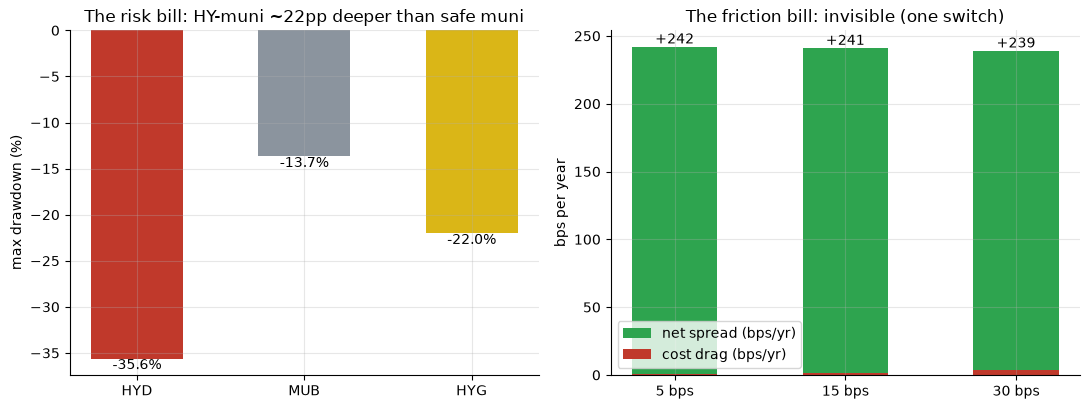

max DD: {'HYD': -35.6, 'MUB': -13.7, 'HYG': -22.0}
  5.0 bps one-way: drag 0.6 bps/yr -> net +242 bps/yr (gross +243)
 15.0 bps one-way: drag 1.7 bps/yr -> net +241 bps/yr (gross +243)
 30.0 bps one-way: drag 3.5 bps/yr -> net +239 bps/yr (gross +243)


In [5]:
if HAVE_REAL:
    dd = {tk: st.max_drawdown(PX[tk].loc['2009-02-01':])['depth_pct'] for tk in ('HYD','MUB','HYG')}
else:
    dd = R['dd']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.2))
a1.bar(['HYD','MUB','HYG'], [dd['HYD'], dd['MUB'], dd['HYG']], color=[RED, GREY, AMBER], width=.55)
for i, k in enumerate(['HYD','MUB','HYG']): a1.annotate(f'{dd[k]:.1f}%', (i, dd[k]), ha='center', va='top')
a1.set_ylabel('max drawdown (%)'); a1.set_title('The risk bill: HY-muni ~22pp deeper than safe muni')
cost_x = [f'{c[0]:.0f} bps' for c in R['costs']]
a2.bar(cost_x, [c[2] for c in R['costs']], color=GREEN, width=.5, label='net spread (bps/yr)')
a2.bar(cost_x, [c[1] for c in R['costs']], color=RED, width=.5, label='cost drag (bps/yr)')
for i, c in enumerate(R['costs']): a2.annotate(f'+{c[2]}', (i, c[2]), ha='center', va='bottom')
a2.set_ylabel('bps per year'); a2.set_title('The friction bill: invisible (one switch)'); a2.legend()
plt.tight_layout(); plt.show()
print('max DD:', {k: round(v,1) for k,v in dd.items()})
for c in R['costs']: print(f'{c[0]:>5.1f} bps one-way: drag {c[1]:.1f} bps/yr -> net {c[2]:+d} bps/yr (gross {R["gross_bps"]:+d})')

> 💡 In plain words: the trade is a **single substitution**, so even 30 bps one-way costs only 3.5 bps/yr against a **+239 bps/yr** net spread — friction does **not** kill it, which is why this is Fragile (thin/crisis-fragile), not Mirage (cost-erased). The real bill is the **-36% vs -14%** drawdown and the crisis inversion: you warehouse illiquid muni-junk exactly when everyone wants out.

### 4e · Faithful-engine control — we know the truth here

A deterministic world HYD = premium + 1.15·MUB + ε with a planted knob. The pipeline must NOT manufacture a premium from the null and MUST recover a planted +3%/yr.

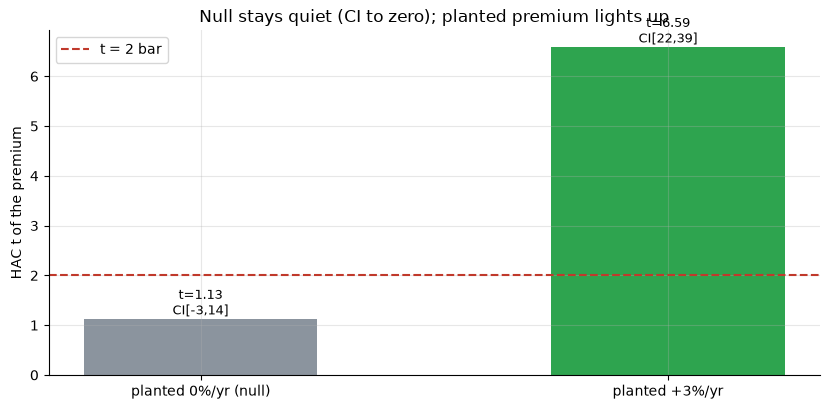

planted +0.0%/yr: mean +5.18 bps/mo  HAC t +1.13  CI [-3.5, +14.1]
planted +3.0%/yr: mean +30.18 bps/mo  HAC t +6.59  CI [+21.5, +39.1]


In [6]:
res = []
for planted in (0.0, 0.03):
    w = data.synthetic_world(premium_annual=planted, seed=887)
    d = st.synthetic_detect(w)
    res.append((planted, d['mean_bps'], d['tstat'], d['ci_low_bps'], d['ci_high_bps']))
fig, ax = plt.subplots(figsize=(8.4, 4.2))
x = np.arange(2)
ax.bar(x, [r[2] for r in res], color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t = 2 bar')
for i, r in enumerate(res): ax.annotate(f't={r[2]:.2f}\nCI[{r[3]:.0f},{r[4]:.0f}]', (i, r[2]), ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(['planted 0%/yr (null)', 'planted +3%/yr'])
ax.set_ylabel('HAC t of the premium'); ax.set_title('Null stays quiet (CI to zero); planted premium lights up'); ax.legend()
plt.tight_layout(); plt.show()
for p, m_, t, lo, hi in res: print(f'planted {p*100:+.1f}%/yr: mean {m_:+.2f} bps/mo  HAC t {t:+.2f}  CI [{lo:+.1f}, {hi:+.1f}]')

> 💡 In plain words: with **zero** planted premium the machinery reads t = 1.13 with a CI that straddles zero (quiet); with **+3%/yr** planted it reads t ≈ 6.6 with a CI clear of zero (loud). The HAC/bootstrap pipeline is faithful. *(A machinery proof only — never cited in support of the real-tape stamps.)*

## 5 · The verdict

- **Signal `WEAK`** — HYD − MUB **+20.21 bps/mo** (HAC **t = 1.80**, n = 208); bootstrap 95% CI **[-1.44, 42.23]** touches zero; neither sub-era clears t = 2; the 2022 spread is **−78 bps/mo (t = −4.35)**. Positive, thin, crisis-fragile — Weak, not Real (and not None: the sign is right and the Sharpe edge is sign-consistent, +0.13/+0.15).
- **Tradability `FRAGILE`** — one switch, drag ≤ 3.5 bps/yr vs **+239 bps/yr net** (costs do **not** erase it → not a Mirage). Fragile: the Signal is thin, the payoff crisis-fragile (DD -35.6% vs -13.7%), and the mechanical tax pickup (TEY 9.2% vs 6.0%; after-tax 5.4% > 4.7%) only helps top-bracket taxable accounts and ties the after-tax Sharpe race.
- **Credit + tax wrapper? `HALF TRUE`** — the wrapper is real and mechanical; the credit premium over IG munis does not certify.

## 6 · Going further

- **It's a liquidity premium, not a default premium.** Munis rarely default; Schwert (2017) shows the muni spread is largely liquidity. That is *why* it inverts in 2020/2022 — a premium paid in calm and clawed back in a scramble is structurally Fragile, whatever its calm-period average.
- **The tax leg is contract, not opinion.** As long as muni coupons are federally exempt and you are top-bracket in a taxable account, TEY 9.2% vs 6.0% holds every month — but it is a *wrapper* advantage, not a risk-adjusted edge, so it earns credit without a green stamp.
- **Siblings:** [Study 610 — Fallen-Angels](../../610-fallen-angels-premium/) is the taxable cousin (a within-junk selection premium that **does** clear t ≥ 2); [Study 576 — Muni-Treasury-Ratio](../../576-muni-treasury-ratio/) (a valuation-timing ratio) and [Study 616 — Muni-CEF-Tax-Loss](../../616-muni-cef-tax-loss/) (a seasonal CEF effect) test other muni folklore; [Study 115 — Credit-Spreads](../../115-credit-spreads/) uses credit as an equity-timing signal.

*The reproducible core is offline and deterministic; every number above is printed by [`examples/verify.py`](../examples/verify.py) and frozen in [`docs/results.md`](../docs/results.md).*